In [46]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False
# symbols: list[str] = ["XRPUSDT","BTCUSDT", "ETHUSDT", "LTCUSDT", "ADAUSDT", "SOLUSDT", "BNBUSDT", "LINKUSDT",
#             "DOGEUSDT", "SHIBUSDT", "PEPEUSDT", "PENGUUSDT","BONKUSDT", "TRUMPUSDT", "SPXUSDT", "FLOKIUSDT", "WIFUSDT"]


# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "5m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/5m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [47]:
major_list = [
    "BTCUSDT",
    "ETHUSDT",
    "LTCUSDT",
    "XRPUSDT",
    "ADAUSDT",
    "SOLUSDT",
    "BNBUSDT",
    "LINKUSDT",
]
meme_list = [
    "DOGEUSDT",
    "SHIBUSDT",
    "PEPEUSDT",
    "PENGUUSDT",
    "BONKUSDT",
    "TRUMPUSDT",
    "SPXUSDT",
    "FLOKIUSDT",
    "WIFUSDT",
]

In [48]:
# by million

volume_dict = {
    "BTCUSDT": 19.92,
    "ETHUSDT": 120.7,
    "XRPUSDT": 59.77 * 1000,
    "BNBUSDT": 139.18,
    "SOLUSDT": 543.03,
    "ADAUSDT": 35.79 * 1000,
    "LINKUSDT": 678.09,
    "LTCUSDT": 76.31,
    "DOGEUSDT": 151 * 1000,
    "SHIBUSDT": 589.24 * 1000000,
    "PEPEUSDT": 420.68 * 1000000,
    "PENGUUSDT": 62.86 * 1000,
    "BONKUSDT": 81.21 * 1000000,
    # "TRUMPUSDT": 199.99,
    "SPXUSDT": 930.99,
    "FLOKIUSDT": 9.53 * 1000000,
    "WIFUSDT": 998.83,
}

In [62]:
from pathlib import Path

import pandas as pd

output_dir = "mmpair-strategy/5m_klines_raw"
output_path = Path(output_dir)

major_1st_mktval = None
major_2st_mktval = None
major_3st_mktval = None
major_rest_mktval = None
meme_1st_mktval = None
meme_2st_mktval = None
meme_3st_mktval = None
meme_rest_mktval = None


major_mktval_dict, meme_mktval_dict = {}, {}

common_index = None  # 用来存放所有文件的共同 Close Time

for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]

        # === 1️⃣ 更新共同 index ===
        if common_index is None:
            common_index = df.index
        else:
            common_index = common_index.intersection(df.index)

        # === 2️⃣ 计算总市值 ===
        close_ts = df["Close"]
        tot_volume = volume_dict.get(symbol, 0)
        tot_value = close_ts * tot_volume / 1e6  # 百万美元

        if symbol in major_list:
            if symbol == "BTCUSDT":
                major_1st_mktval = tot_value
            elif symbol == "ETHUSDT":
                major_2st_mktval = tot_value
            elif symbol == "SOLUSDT":
                major_3st_mktval = tot_value

            else:
                major_rest_mktval = (
                    major_rest_mktval.add(tot_value, fill_value=0)
                    if major_rest_mktval is not None
                    else tot_value.copy()
                )
            major_mktval_dict[symbol] = tot_value

        elif symbol in meme_list:
            if symbol == "DOGEUSDT":
                meme_1st_mktval = tot_value
            elif symbol == "SHIBUSDT":
                meme_2st_mktval = tot_value
            elif symbol == "WIFUSDT":
                meme_3st_mktval = tot_value
            else:
                meme_rest_mktval = (
                    meme_rest_mktval.add(tot_value, fill_value=0)
                    if meme_rest_mktval is not None
                    else tot_value.copy()
                )
            meme_mktval_dict[symbol] = tot_value
# ...existing code...

# 获取前一半的 index
if common_index is not None:
    half_len = len(common_index) // 2
    half_index = common_index[half_len:]

    # 对所有相关变量裁剪
    if major_1st_mktval is not None:
        major_1st_mktval = major_1st_mktval.reindex(half_index)
    if major_2st_mktval is not None:
        major_2st_mktval = major_2st_mktval.reindex(half_index)
    if major_3st_mktval is not None:
        major_3st_mktval = major_3st_mktval.reindex(half_index)
    if major_rest_mktval is not None:
        major_rest_mktval = major_rest_mktval.reindex(half_index)
    if meme_1st_mktval is not None:
        meme_1st_mktval = meme_1st_mktval.reindex(half_index)
    if meme_2st_mktval is not None:
        meme_2st_mktval = meme_2st_mktval.reindex(half_index)
    if meme_3st_mktval is not None:
        meme_3st_mktval = meme_3st_mktval.reindex(half_index)
    if meme_rest_mktval is not None:
        meme_rest_mktval = meme_rest_mktval.reindex(half_index)

    # 字典也裁剪
    for k in major_mktval_dict:
        major_mktval_dict[k] = major_mktval_dict[k].reindex(half_index)
    for k in meme_mktval_dict:
        meme_mktval_dict[k] = meme_mktval_dict[k].reindex(half_index)

    # 更新 common_index
    common_index = half_index

print("✅ 已裁剪为前一半，长度:", len(common_index))

✅ 已裁剪为前一半，长度: 32349


In [63]:
major_rest_mktval

Close Time
2025-05-11 16:19:59.999999    0.277291
2025-05-11 16:24:59.999999    0.278546
2025-05-11 16:29:59.999999    0.278723
2025-05-11 16:34:59.999999    0.278221
2025-05-11 16:39:59.999999    0.278162
                                ...   
2025-08-31 23:39:59.999999    0.338436
2025-08-31 23:44:59.999999    0.338215
2025-08-31 23:49:59.999999    0.338651
2025-08-31 23:54:59.999999    0.338404
2025-08-31 23:59:59.999999    0.338349
Freq: 5min, Name: Close, Length: 32349, dtype: float64

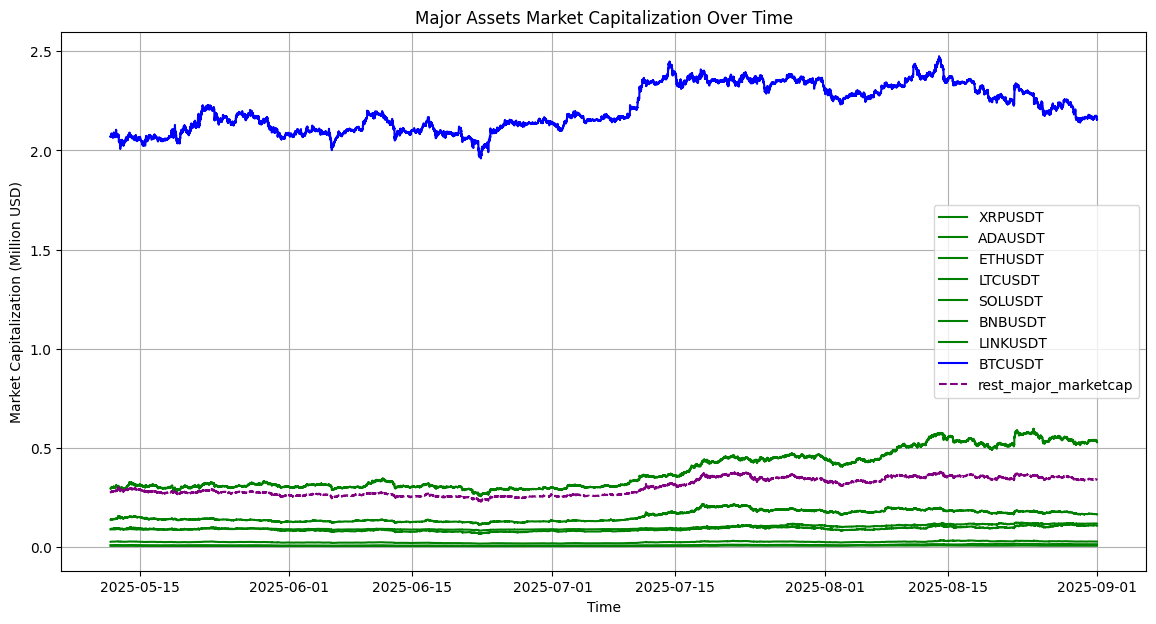

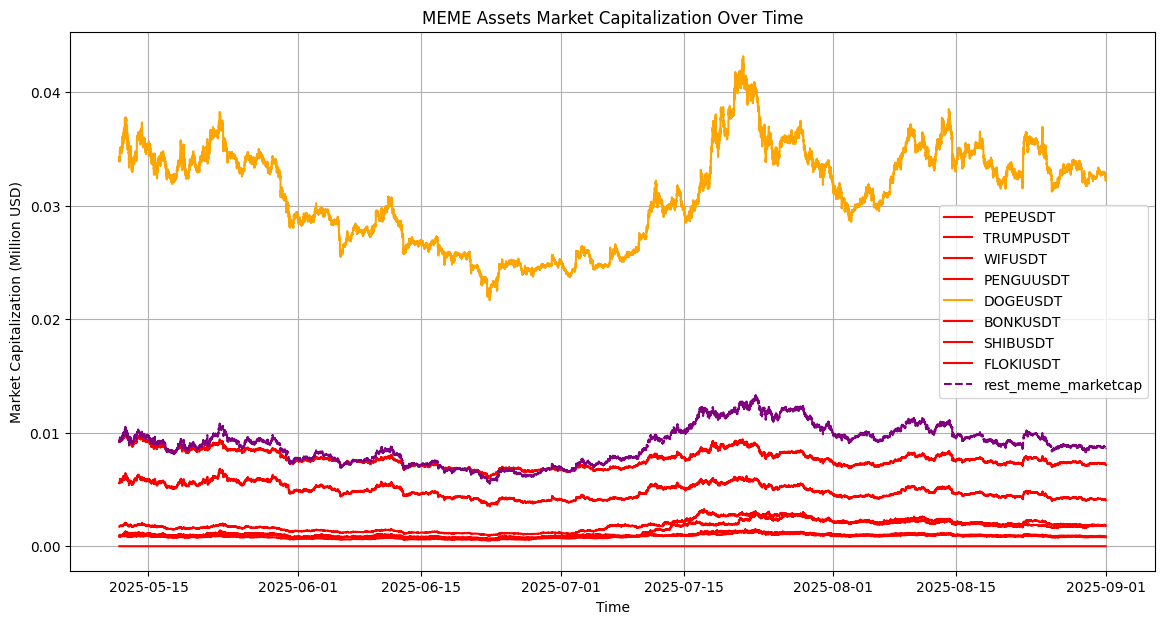

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for symbol, mktval in major_mktval_dict.items():
    plt.plot(
        mktval.index,
        mktval,
        label=symbol,
        color="blue" if symbol == "BTCUSDT" else "green",
    )
plt.plot(
    major_rest_mktval.index,
    major_rest_mktval,
    label="rest_major_marketcap",
    color="purple",
    linestyle="--",
)
plt.title("Major Assets Market Capitalization Over Time")
plt.xlabel("Time")
plt.ylabel("Market Capitalization (Million USD)")
plt.legend()
plt.grid()
plt.show()
plt.close()


plt.figure(figsize=(14, 7))
for symbol, mktval in meme_mktval_dict.items():
    plt.plot(
        mktval.index,
        mktval,
        label=symbol,
        color="orange" if symbol == "DOGEUSDT" else "red",
    )
plt.plot(
    meme_rest_mktval.index,
    meme_rest_mktval,
    label="rest_meme_marketcap",
    color="purple",
    linestyle="--",
)
plt.title("MEME Assets Market Capitalization Over Time")
plt.xlabel("Time")
plt.ylabel("Market Capitalization (Million USD)")
plt.legend()
plt.grid()
plt.show()
plt.close()

In [65]:
import matplotlib.pyplot as plt
import pandas as pd


def lead_lag_correlation(
    series1: pd.Series, series2: pd.Series, max_lag: int = 24, interval: int = 3
):
    """Measure the lead-lag correlation between two time series and visualize the effect of shifting timestamps.

    Parameters:
      series1 (pd.Series): The first time series.
      series2 (pd.Series): The second time series.
      max_lag (int): The maximum number of timestamps to shift forward and backward.

    Returns:
      pd.Series: A series containing the correlation values for each lag/lead.
    """
    correlations = {}

    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            # series1 leads series2
            shifted_series2 = series2.shift(-lag * interval)
            corr = series1.corr(shifted_series2)
        elif lag > 0:
            # series2 leads series1
            shifted_series1 = series1.shift(lag * interval)
            corr = shifted_series1.corr(series2)
        else:
            # No lag
            corr = series1.corr(series2)

        correlations[lag] = corr

    # Convert to pandas Series for easier handling
    correlation_series = pd.Series(correlations)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(
        correlation_series.index, correlation_series.values, marker="o", linestyle="-"
    )
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.title("Lead-Lag Correlation")
    plt.xlabel("Lag (timestamps)")
    plt.ylabel("Correlation")
    plt.grid()
    plt.show()

    return correlation_series

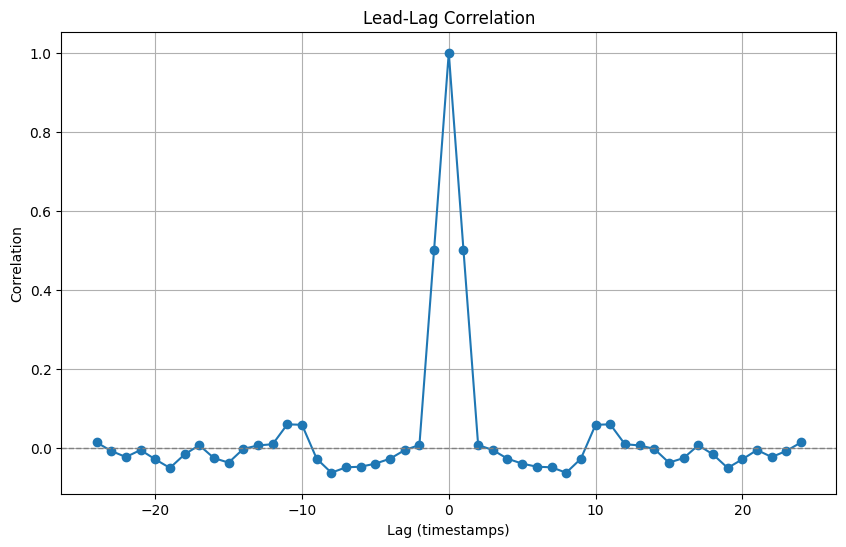

-24    0.012962
-23   -0.008579
-22   -0.024098
-21   -0.006308
-20   -0.029818
-19   -0.051745
-18   -0.017415
-17    0.005772
-16   -0.026684
-15   -0.038316
-14   -0.003523
-13    0.005336
-12    0.008274
-11    0.058724
-10    0.057567
-9    -0.028376
-8    -0.063844
-7    -0.050132
-6    -0.048624
-5    -0.040802
-4    -0.028331
-3    -0.006452
-2     0.006452
-1     0.501059
 0     1.000000
 1     0.501059
 2     0.006452
 3    -0.006452
 4    -0.028331
 5    -0.040802
 6    -0.048624
 7    -0.050132
 8    -0.063844
 9    -0.028376
 10    0.057567
 11    0.058724
 12    0.008274
 13    0.005336
 14   -0.003523
 15   -0.038316
 16   -0.026684
 17    0.005772
 18   -0.017415
 19   -0.051745
 20   -0.029818
 21   -0.006308
 22   -0.024098
 23   -0.008579
 24    0.012962
dtype: float64

In [66]:
# 计算 major_1st_mktval 相隔12个时间戳的涨幅
major_1st_returns = major_1st_mktval.pct_change(periods=60)

# 计算 major_rest_mktval 相隔12个时间戳的涨幅
major_1st_returns = major_1st_mktval.pct_change(periods=60)

# 使用涨幅序列作为 lead_lag_correlation 的输入
lead_lag_correlation(major_1st_returns, major_1st_returns, max_lag=24, interval=30)

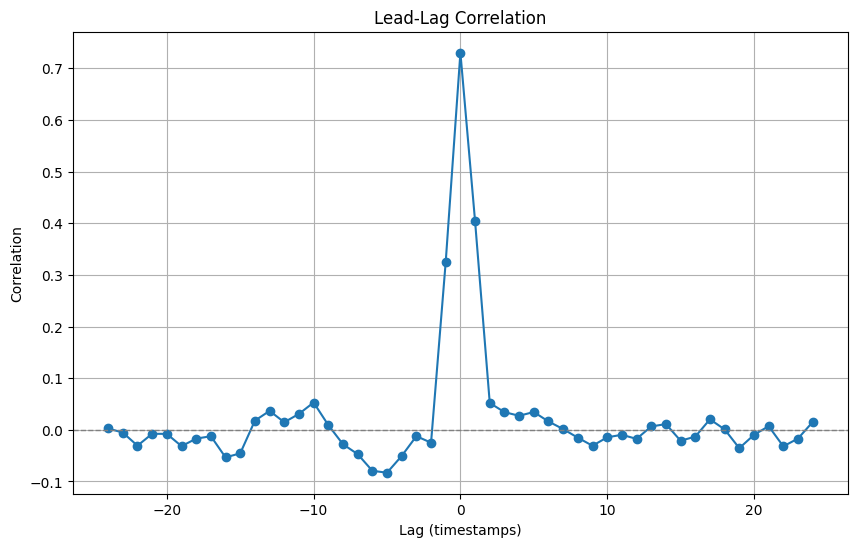

-24    0.002560
-23   -0.005409
-22   -0.030771
-21   -0.007685
-20   -0.007927
-19   -0.031675
-18   -0.017123
-17   -0.012451
-16   -0.053444
-15   -0.045597
-14    0.017712
-13    0.036584
-12    0.014589
-11    0.030789
-10    0.052824
-9     0.009105
-8    -0.027983
-7    -0.047155
-6    -0.079364
-5    -0.083138
-4    -0.050686
-3    -0.012374
-2    -0.024981
-1     0.325415
 0     0.730158
 1     0.403684
 2     0.051911
 3     0.034171
 4     0.027128
 5     0.034417
 6     0.016113
 7     0.001371
 8    -0.015325
 9    -0.030895
 10   -0.014603
 11   -0.009670
 12   -0.017586
 13    0.006420
 14    0.011060
 15   -0.021118
 16   -0.013306
 17    0.020240
 18    0.000832
 19   -0.035603
 20   -0.009846
 21    0.007002
 22   -0.032083
 23   -0.016943
 24    0.015054
dtype: float64

In [67]:
# 计算 major_1st_mktval 相隔12个时间戳的涨幅
major_1st_returns = major_1st_mktval.pct_change(periods=60)

# 计算 major_rest_mktval 相隔12个时间戳的涨幅
major_rest_returns = major_rest_mktval.pct_change(periods=60)

# 使用涨幅序列作为 lead_lag_correlation 的输入
lead_lag_correlation(major_1st_returns, major_rest_returns, max_lag=24, interval=30)

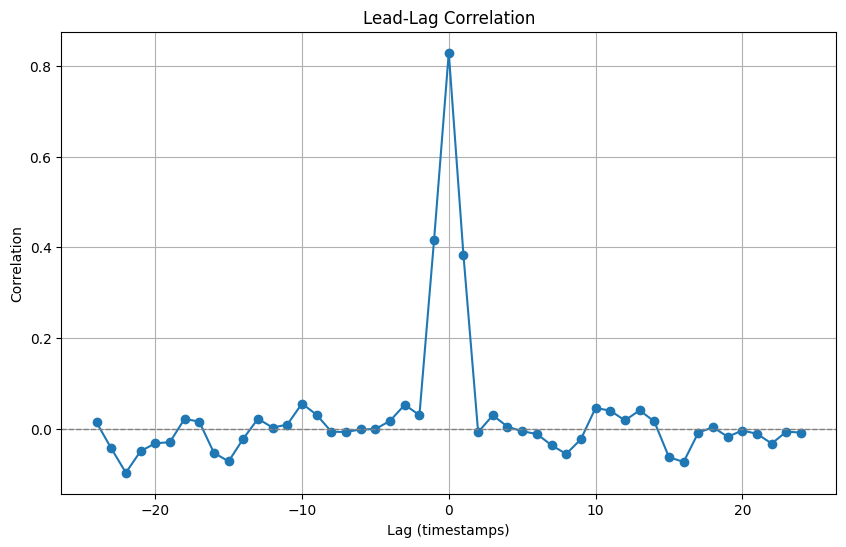

-24    0.013692
-23   -0.043312
-22   -0.097344
-21   -0.049855
-20   -0.032444
-19   -0.029919
-18    0.021598
-17    0.015297
-16   -0.053390
-15   -0.072298
-14   -0.022305
-13    0.021831
-12    0.002192
-11    0.008978
-10    0.055208
-9     0.030354
-8    -0.006883
-7    -0.007405
-6    -0.001872
-5    -0.001094
-4     0.017191
-3     0.052658
-2     0.029687
-1     0.417261
 0     0.829422
 1     0.383083
 2    -0.007860
 3     0.029354
 4     0.004234
 5    -0.005853
 6    -0.011920
 7    -0.036525
 8    -0.056030
 9    -0.023386
 10    0.045522
 11    0.039681
 12    0.017977
 13    0.040327
 14    0.015903
 15   -0.062999
 16   -0.073552
 17   -0.008873
 18    0.002999
 19   -0.017902
 20   -0.004221
 21   -0.011480
 22   -0.033011
 23   -0.006706
 24   -0.008803
dtype: float64

In [68]:
# 计算 major_1st_mktval 相隔12个时间戳的涨幅
meme_1st_returns = meme_1st_mktval.pct_change(periods=60)

# 计算 major_rest_mktval 相隔12个时间戳的涨幅
meme_rest_returns = meme_rest_mktval.pct_change(periods=60)

# 使用涨幅序列作为 lead_lag_correlation 的输入
lead_lag_correlation(meme_1st_returns, meme_rest_returns, max_lag=24, interval=30)

In [69]:
_1st_major_to_meme_ratio = major_1st_mktval / meme_1st_mktval
# _2st_major_to_meme_ratio = major_2st_mktval / meme_2st_mktval
_3st_major_to_meme_ratio = major_3st_mktval / meme_3st_mktval
rest_major_to_meme_ratio = major_rest_mktval / meme_rest_mktval

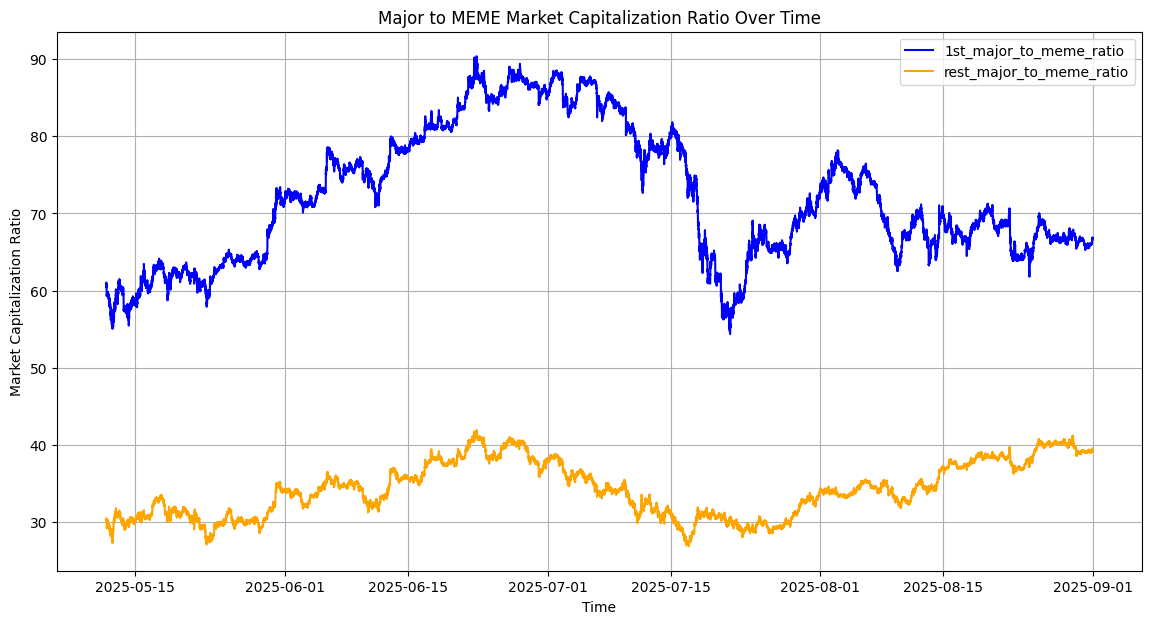

In [70]:
plt.figure(figsize=(14, 7))
plt.plot(
    _1st_major_to_meme_ratio.index,
    _1st_major_to_meme_ratio,
    label="1st_major_to_meme_ratio",
    color="blue",
)
plt.plot(
    rest_major_to_meme_ratio.index,
    rest_major_to_meme_ratio,
    label="rest_major_to_meme_ratio",
    color="orange",
)
plt.title("Major to MEME Market Capitalization Ratio Over Time")
plt.xlabel("Time")
plt.ylabel("Market Capitalization Ratio")
plt.legend()
plt.grid()
plt.show()
plt.close()

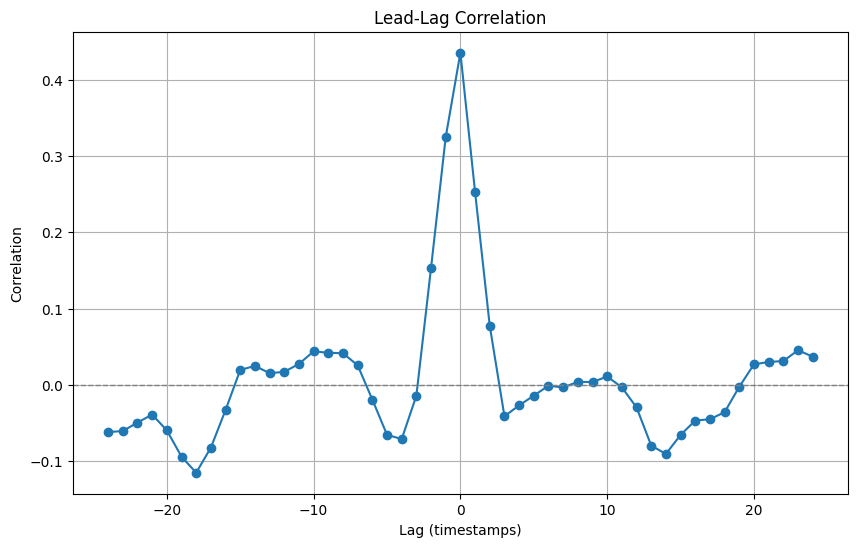

-24   -0.061760
-23   -0.060429
-22   -0.049329
-21   -0.038850
-20   -0.059533
-19   -0.094025
-18   -0.115020
-17   -0.082149
-16   -0.032913
-15    0.019605
-14    0.024870
-13    0.015382
-12    0.017111
-11    0.027474
-10    0.043928
-9     0.042105
-8     0.041465
-7     0.025723
-6    -0.019205
-5    -0.065386
-4    -0.070953
-3    -0.014185
-2     0.153418
-1     0.324728
 0     0.435119
 1     0.252588
 2     0.077352
 3    -0.041046
 4    -0.026805
 5    -0.014058
 6    -0.001035
 7    -0.003330
 8     0.004080
 9     0.003722
 10    0.011018
 11   -0.003155
 12   -0.029473
 13   -0.079427
 14   -0.090479
 15   -0.065494
 16   -0.046632
 17   -0.044978
 18   -0.035738
 19   -0.002414
 20    0.026924
 21    0.030035
 22    0.031269
 23    0.045441
 24    0.036991
dtype: float64

In [71]:
# 计算 major_1st_mktval 相隔12个时间戳的涨幅
_1st_m2m_returns = _1st_major_to_meme_ratio.pct_change(periods=-96)

# 计算 major_rest_mktval 相隔12个时间戳的涨幅
_2st_m2m_returns = _3st_major_to_meme_ratio.pct_change(periods=-96)

# 使用涨幅序列作为 lead_lag_correlation 的输入
lead_lag_correlation(_1st_m2m_returns, _2st_m2m_returns, max_lag=24, interval=36)

In [72]:
_1st_major_to_meme_ratio

Close Time
2025-05-11 16:19:59.999999    61.006919
2025-05-11 16:24:59.999999    60.501734
2025-05-11 16:29:59.999999    60.403481
2025-05-11 16:34:59.999999    60.422827
2025-05-11 16:39:59.999999    60.561498
                                ...    
2025-08-31 23:39:59.999999    66.857214
2025-08-31 23:44:59.999999    66.870126
2025-08-31 23:49:59.999999    66.832512
2025-08-31 23:54:59.999999    66.804129
2025-08-31 23:59:59.999999    66.819128
Freq: 5min, Name: Close, Length: 32349, dtype: float64

In [73]:
_1st_major_to_meme_ratio.shift(1)

Close Time
2025-05-11 16:19:59.999999          NaN
2025-05-11 16:24:59.999999    61.006919
2025-05-11 16:29:59.999999    60.501734
2025-05-11 16:34:59.999999    60.403481
2025-05-11 16:39:59.999999    60.422827
                                ...    
2025-08-31 23:39:59.999999    66.740937
2025-08-31 23:44:59.999999    66.857214
2025-08-31 23:49:59.999999    66.870126
2025-08-31 23:54:59.999999    66.832512
2025-08-31 23:59:59.999999    66.804129
Freq: 5min, Name: Close, Length: 32349, dtype: float64

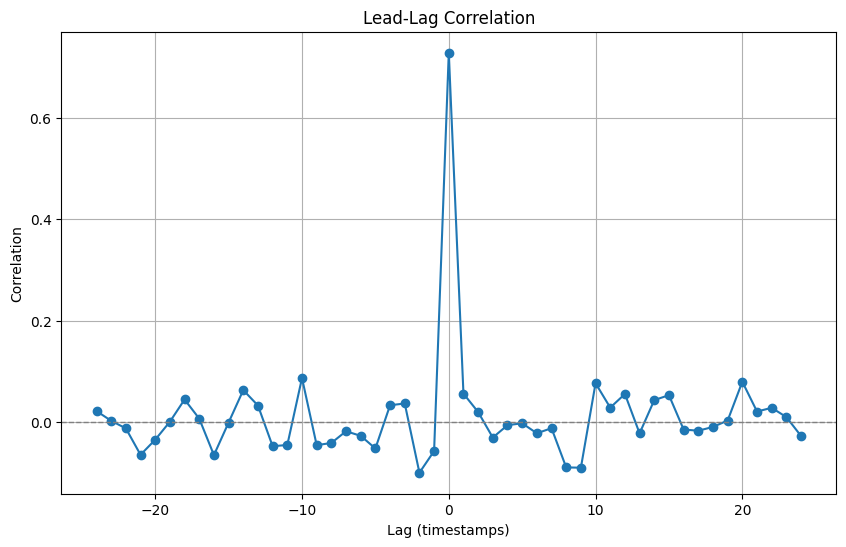

-24    0.021392
-23    0.002167
-22   -0.012761
-21   -0.064919
-20   -0.035128
-19    0.000351
-18    0.044209
-17    0.006447
-16   -0.065537
-15   -0.001234
-14    0.062752
-13    0.032295
-12   -0.047989
-11   -0.045528
-10    0.086530
-9    -0.045879
-8    -0.041591
-7    -0.018433
-6    -0.027530
-5    -0.052401
-4     0.032891
-3     0.036330
-2    -0.100283
-1    -0.057514
 0     0.728491
 1     0.055799
 2     0.019471
 3    -0.030939
 4    -0.006433
 5    -0.002728
 6    -0.022453
 7    -0.012418
 8    -0.089770
 9    -0.090397
 10    0.076290
 11    0.028157
 12    0.055090
 13   -0.022602
 14    0.043037
 15    0.052755
 16   -0.015038
 17   -0.017408
 18   -0.009917
 19    0.002710
 20    0.079227
 21    0.020478
 22    0.027820
 23    0.009496
 24   -0.027771
dtype: float64

In [74]:
# major_1st_mktval
# major_rest_mktval
# meme_1st_mktval
# meme_rest_mktval


# 计算 major_1st_mktval 相隔12个时间戳的涨幅
_1st_m2m_returns = major_1st_mktval.pct_change(periods=96)

# 计算 major_rest_mktval 相隔12个时间戳的涨幅
rest_m2m_returns = major_rest_mktval.pct_change(periods=96)

# 使用涨幅序列作为 lead_lag_correlation 的输入
lead_lag_correlation(_1st_m2m_returns, rest_m2m_returns, max_lag=24, interval=96)